
# This file contain EDA analysis of A&E NHS dataset
- (Accident and Emergency)

In [146]:
# importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/Monthly-AE-February-2025-revised.csv")   # for now just one file to explore the data 
df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-FEBRUARY-2025,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,545,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,MSitAE-FEBRUARY-2025,RAN,NHS ENGLAND LONDON,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
2,MSitAE-FEBRUARY-2025,RW1,NHS ENGLAND SOUTH EAST,HAMPSHIRE AND ISLE OF WIGHT HEALTHCARE NHS FOU...,0,0,2518,0,0,0,...,37,0,0,0,0,0,0,0,0,119
3,MSitAE-FEBRUARY-2025,RWY,NHS ENGLAND NORTH EAST AND YORKSHIRE,CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST,14096,0,0,0,0,0,...,0,0,0,0,1144,48,2486,0,0,189
4,MSitAE-FEBRUARY-2025,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,279,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [147]:
df.shape

(199, 22)

In [148]:
df.columns.to_list()

['Period',
 'Org Code',
 'Parent Org',
 'Org name',
 'A&E attendances Type 1',
 'A&E attendances Type 2',
 'A&E attendances Other A&E Department',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'Attendances over 4hrs Type 1',
 'Attendances over 4hrs Type 2',
 'Attendances over 4hrs Other Department',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'Patients who have waited 12+ hrs from DTA to admission',
 'Emergency admissions via A&E - Type 1',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'Other emergency admissions']

# Attendance types 
- Type 1 are the major A&E. Full emergency department
- Type 2 are the single specialty. Eye casualty, dental emergency.
- Type other A&E departments are the minor injury units, urgent treatment centres. Walk-in level stuff.

# what I care most for training 
- Type 1 
-  'Patients who have waited 4-12 hs from DTA to admission'  (Decision To Admit)
- 'Patients who have waited 12+ hrs from DTA to admission'

** Booked Appointments will be taken least into account **

In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 22 columns):
 #   Column                                                      Non-Null Count  Dtype
---  ------                                                      --------------  -----
 0   Period                                                      199 non-null    str  
 1   Org Code                                                    199 non-null    str  
 2   Parent Org                                                  199 non-null    str  
 3   Org name                                                    199 non-null    str  
 4   A&E attendances Type 1                                      199 non-null    int64
 5   A&E attendances Type 2                                      199 non-null    int64
 6   A&E attendances Other A&E Department                        199 non-null    int64
 7   A&E attendances Booked Appointments Type 1                  199 non-null    int64
 8   A&E attendances Booked Appointm

In [150]:
# renaming the long descriptives columns names 
df = df.rename(columns={
    'Period': 'period',
    'Org Code': 'org_code',
    'Parent Org': 'parent_org',
    'Org name': 'org_name',
    'A&E attendances Type 1': 'type1_att',
    'A&E attendances Type 2': 'type2_att',
    'Attendances over 4hrs Type 1': 'type1_breach',
    'Attendances over 4hrs Type 2': 'type2_breach',
    'Attendances over 4hrs Other Department': 'other_breach',
    'Patients who have waited 12+ hrs from DTA to admission': 'wait_12plus',
    'Emergency admissions via A&E - Type 1': 'type1_admissions',
    'Other emergency admissions': 'other_admissions'
})

df.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'type1_att',
 'type2_att',
 'A&E attendances Other A&E Department',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'type1_breach',
 'type2_breach',
 'other_breach',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'wait_12plus',
 'type1_admissions',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'other_admissions']

In [151]:
df.describe()

,type1_att,type2_att,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,type1_breach,type2_breach,other_breach,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,wait_12plus,type1_admissions,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,other_admissions
count,1.990000e+02,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,1.248172e+04,452.974874,7250.864322,295.527638,6.140704,498.412060,5242.402010,18.603015,223.175879,79.226131,0.301508,5.597990,840.341709,478.623116,3644.271357,12.582915,37.396985,1291.628141
std,8.782205e+04,3241.855092,51010.808992,2109.743191,54.921526,3568.935856,36889.266797,136.108870,1579.689943,570.645677,2.999924,40.636467,5922.473024,3376.645621,25647.129880,104.627294,270.493205,9109.228811
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000,829.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.286000e+03,0.000000,2654.000000,0.000000,0.000000,0.000000,2555.000000,0.000000,17.000000,0.000000,0.000000,0.000000,278.000000,24.000000,1592.000000,0.000000,0.000000,291.000000
75%,1.013150e+04,0.000000,5704.000000,62.000000,0.000000,146.000000,4257.000000,0.000000,156.500000,0.500000,0.000000,0.000000,682.500000,436.500000,2959.500000,0.000000,0.000000,1041.000000
max,1.241931e+06,45071.000000,721461.000000,29405.000000,611.000000,49592.000000,521619.000000,1851.000000,22206.000000,7883.000000,30.000000,557.000000,83614.000000,47623.000000,362605.000000,1252.000000,3721.000000,128517.000000


In [152]:
df = df[df["type1_att"] > 0]   # here I extract the hostpitals those attendance type 1 are 0 cuz it shows that hospital dont deal with type 1 patients so the rows where type 1 attendance are 0 is dropped
df.shape

(122, 22)

In [153]:
df["breach_rate"] = df["type1_breach"] / df['type1_att']   # finding (out of total attendance of one hospital how many patients are treated above 4-hr timer )
df["breach_rate"].head(10)

3     0.317182
11    0.431753
30    0.463124
31    0.454003
32    0.522547
33    0.387703
34    0.341764
35    0.304440
40    0.517669
41    0.483328
Name: breach_rate, dtype: float64

In [154]:
df['breached'] = np.where(df["breach_rate"] > 0.30, 1, 0)   #Adding the target variable into dataset which is breached (1 means beached,0 means not breached)
df['breached'].value_counts()

breached
1    114
0      8
Name: count, dtype: int64

In [155]:
df = df[df['org_name'] != 'TOTAL']   # Extracting the row of total from the dataset
df.shape

(121, 24)

# Graphs to analyse the data 

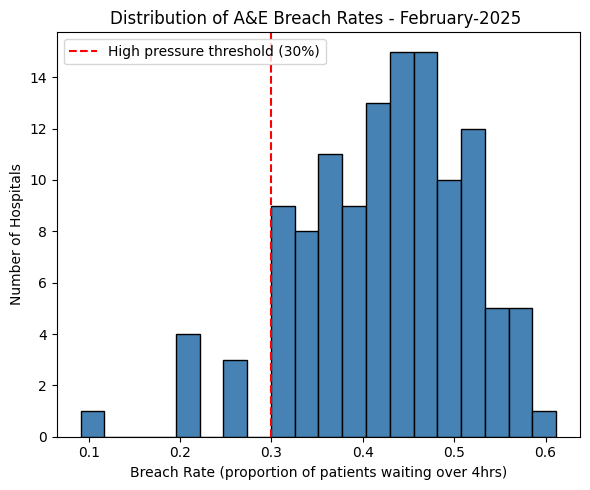

In [156]:
# histogram between the total no of hospitals and their breach rate  
plt.figure(figsize=(6, 5))

plt.hist(x=df["breach_rate"], bins=20, color="steelblue",edgecolor='black')
plt.axvline(x=0.30,color= 'red' , linestyle = '--', label= 'High pressure threshold (30%)')
plt.title('Distribution of A&E Breach Rates - February-2025 ')
plt.xlabel("Breach Rate (proportion of patients waiting over 4hrs)")
plt.ylabel("Number of Hospitals")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/01_breach_rate_distribution.png")
plt.show()

- This graphs shows that most of the hospitals have 40 to 50% breach rate. which means that the problem is not only with the few hospitals 
- The red line in this spliting the hospitals into 2 groups, one(left side) having breach less than 30 percent and other(right) having breach more than the threshold 

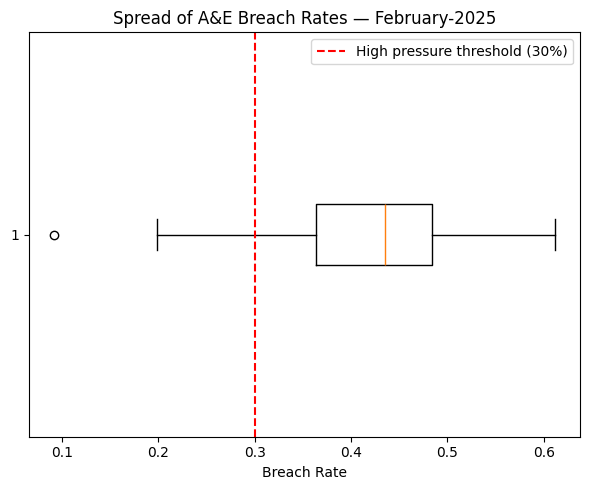

In [157]:
# box plot :how spread out the breach rates are across all hospitals
plt.figure(figsize=(6, 5))

plt.boxplot(df['breach_rate'], vert=False)

plt.axvline(x=0.30, color='red', linestyle='--', label='High pressure threshold (30%)')

plt.title('Spread of A&E Breach Rates — February-2025')
plt.xlabel('Breach Rate')
plt.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/02_breach_rate_boxplot.png')
plt.show()

- The typical NHS hospital has 43% breach rate and most the hospitals breach rate ranges from 35% to 50% ,only one outlier hospital which need to be investigating 

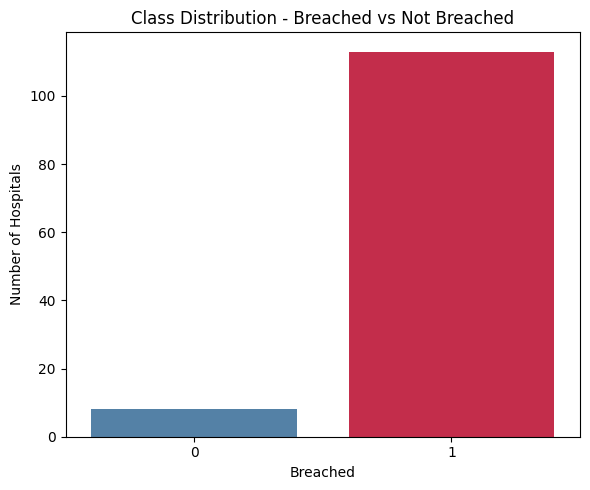

In [158]:
# countplot : how many hospitals breached vs didn't breach

plt.figure(figsize=(6,5))
sns.countplot(x='breached',hue='breached',data=df,palette=['steelblue', 'crimson'], legend=False)
plt.title("Class Distribution - Breached vs Not Breached")
plt.xlabel('Breached')
plt.ylabel('Number of Hospitals')

plt.tight_layout()
plt.savefig('../outputs/figures/03_class_distribution.png')
plt.show()

- Graph shows that only 18 hospitals were not breached , all the other breached (breach rate above 
30%) in Feb 2025. 
- This confirms class imbalance in the dataset. The model will see far more 
breached examples than not breached. This needs to be handled during 
training using techniques like class_weight to prevent the model from simply 
predicting breach for every hospital.

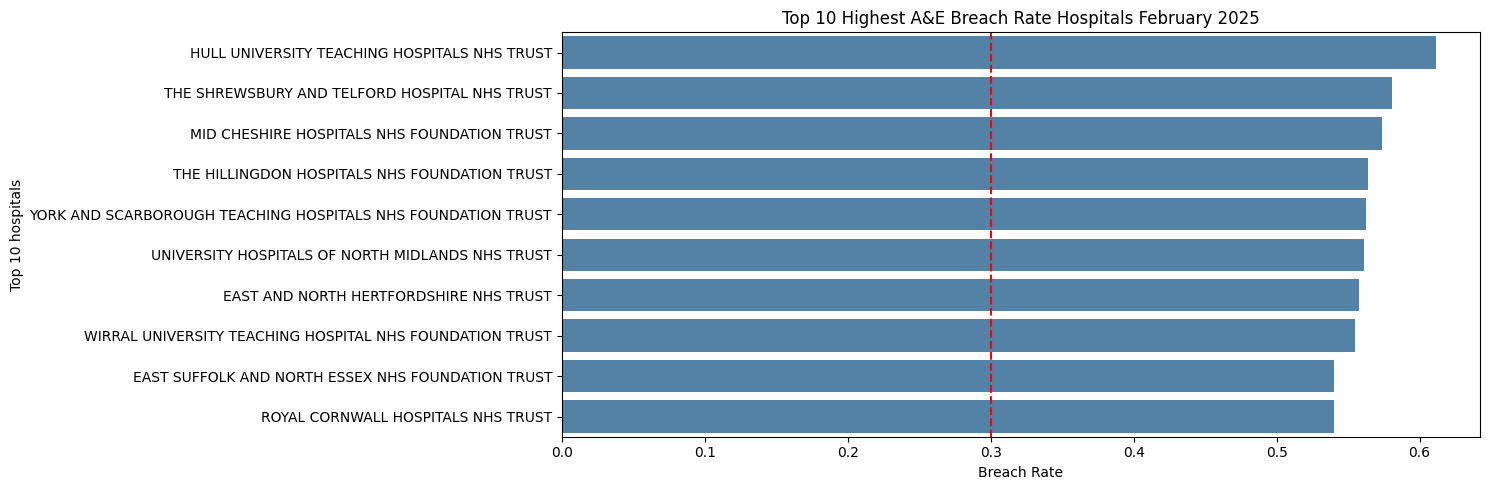

In [159]:
 # specific hospital names with their breach rates (top 10)

top10 = df.sort_values('breach_rate',ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(x='breach_rate',y="org_name", data=top10, color="steelblue")
plt.axvline(x=0.30,color='red',linestyle= '--',label = 'High pressure threshold (30%)')

plt.title('Top 10 Highest A&E Breach Rate Hospitals February 2025')
plt.xlabel('Breach Rate')
plt.ylabel("Top 10 hospitals")

plt.tight_layout()
plt.savefig('../outputs/figures/04_top10_worst_hospitals.png')
plt.show()

- This graph shows the breach rate of top 10 hospitals and most of them have the breach rate above 50%.

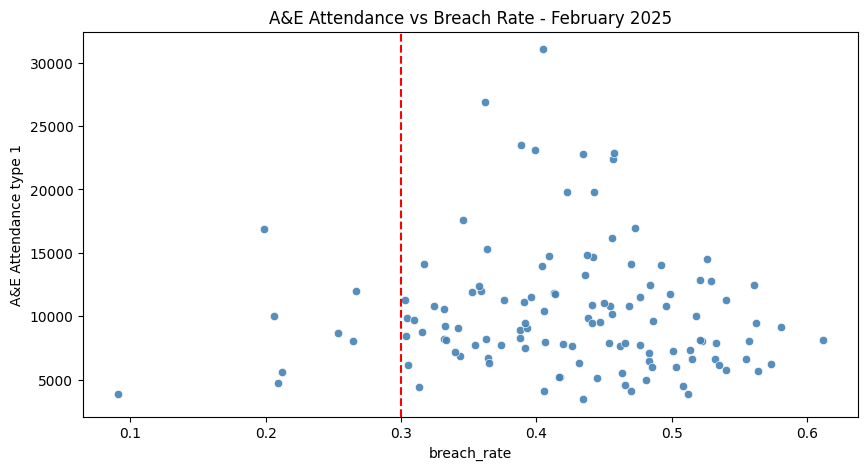

In [160]:
# Does a busier hospital always have a higher breach rate?

plt.figure(figsize=(10,5))
sns.scatterplot(x='breach_rate', y='type1_att', data= df, color= 'steelblue', alpha= 0.9)
plt.axvline(x=0.30,color="red",linestyle = '--', label= "High pressure threshold (30%)")
plt.title("A&E Attendance vs Breach Rate - February 2025")
plt.xlabel("breach_rate")
plt.ylabel("A&E Attendance type 1")

plt.savefig("../outputs/figures/05_attendance_vs_breach.png")
plt.show()

- This graph shows that busier hospitals does not be those who have high breaches , meaning that the attendance of such hospitals doesnt have a correlation with  the breach rate which makes the attendance type 1 feature less involed in breaches 